# Extended Data Figure 6

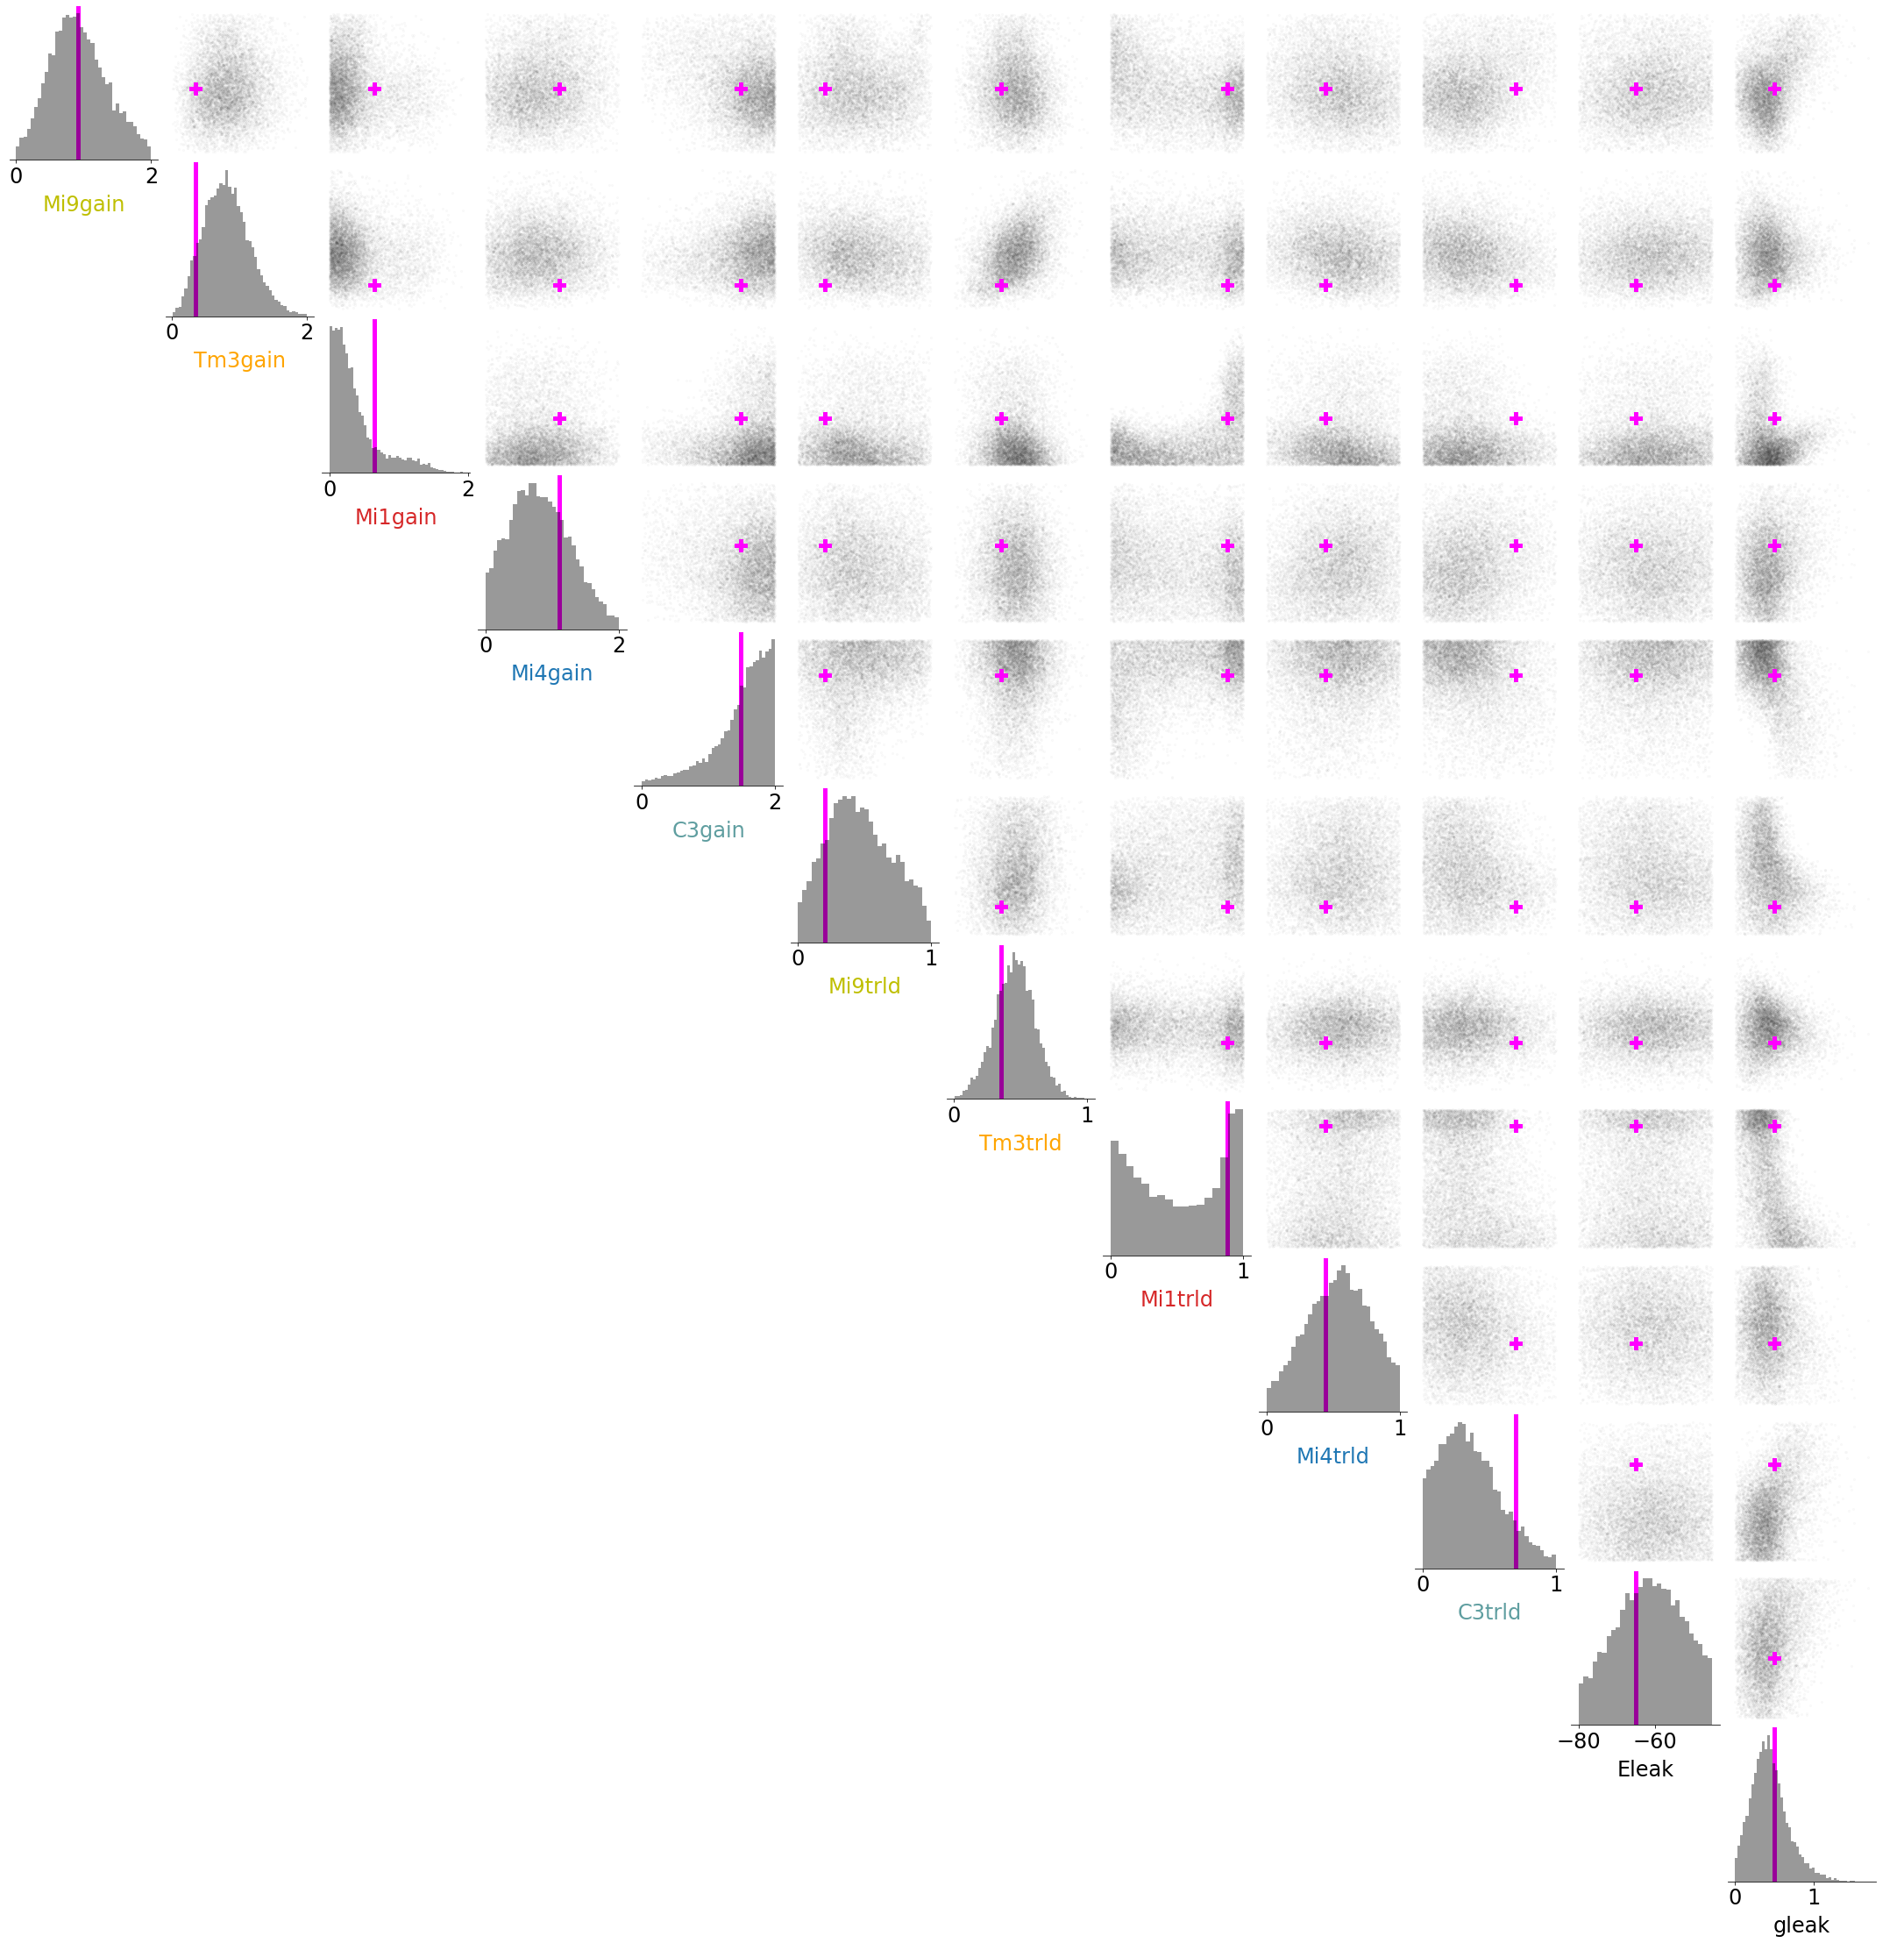

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load drawn posterior samples:
df = pd.read_csv('edfig6_posterior.csv', index_col=None)

# Plot:
# Free parameters used in Fig. 3b, 5a, Extended Data Fig. 7, 8:
# Synaptic weights/gains:
Mi9gain = 0.92
Tm3gain = 0.35
Mi1gain = 0.65
Mi4gain = 1.1
C3gain = 1.49

# Thresholds:
Mi9trld = 0.20
Tm3trld = 0.35
Mi1trld = 0.88 
Mi4trld = 0.44
C3trld = 0.70

# Leak conductance:
gleak = 0.50
Eleak = -65.0

params = np.array([Mi9gain, Tm3gain, Mi1gain, Mi4gain, C3gain,
                   Mi9trld, Tm3trld, Mi1trld, Mi4trld, C3trld,
                   Eleak, gleak])
labels = ['Mi9gain', 'Tm3gain', 'Mi1gain', 'Mi4gain', 'C3gain',
          'Mi9trld', 'Tm3trld', 'Mi1trld', 'Mi4trld', 'C3trld',
          'Eleak', 'gleak']
colours = ['y', 'orange', 'C3', 'C0', 'cadetblue',
           'y', 'orange', 'C3', 'C0', 'cadetblue',
           'k', 'k']

def hide_ax(*args, **kwds):
    plt.gca().set_visible(False)

def remove_ax(*args, **kwds):
    ax = plt.gca()
    ax.set_axis_off()

# Plot:
g = sns.PairGrid(df, diag_sharey=False, layout_pad=-0.7)
g.map_upper(plt.scatter, s=5, color='k', alpha=0.02)
g.map_upper(remove_ax)
g.map_diag(sns.distplot, kde=False, kde_kws={"shade": True}, hist=True, color='k')
g.map_lower(hide_ax)

for idx, l in enumerate(labels):
    for j in range(len(params)):
        g.axes[j,idx].set_xlabel(l, fontsize=24, labelpad=8, color=colours[idx])
        g.axes[j,idx].xaxis.set_tick_params(labelbottom=True, labelsize=24)
        g.axes[j,idx].get_yaxis().set_visible(False)
        g.axes[j,idx].spines['left'].set_visible(False)

for h in range(1,len(params)):
    for i in range(h,len(params)):
        g.axes[h-1,i].scatter(params[i], params[h-1], c='magenta', marker='P', s=200)

for i in range(len(params)):
    g.axes[i,i].axvline(params[i], linewidth=5, color='magenta')
        
plt.show();    
#plt.savefig('samples_min_max.png', bbox_inches='tight');